<a href="https://www.kaggle.com/code/sonawanelalitsunil/furniture-orders-2025-delivery-ml-82-22?scriptVersionId=257223721" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/online-furniture-orders-delivery-and-assembly-2025/online_furniture_retailer.db
/kaggle/input/online-furniture-orders-delivery-and-assembly-2025/online_furniture_retailer.csv
/kaggle/input/online-furniture-orders-delivery-and-assembly-2025/online_furniture_retailer.xlsx
/kaggle/input/online-furniture-orders-delivery-and-assembly-2025/online_furniture_retailer.json


## Title:
📦🛋️ Furniture Orders 2025: Delivery & Assembly Trends

## Detailed Description:
The 2025 Online Furniture Orders: Delivery & Assembly report highlights the growing shift toward e-commerce in the home furnishing sector. It explores how customers prefer seamless delivery, faster turnaround times, eco-friendly packaging, and professional assembly services. The analysis covers consumer expectations, logistics innovations, last-mile delivery challenges, DIY vs. assisted assembly preferences, and the role of AI, AR, and automation in enhancing the online furniture buying experience. This report provides valuable insights for retailers, manufacturers, and logistics providers looking to optimize operations and improve customer satisfaction in the evolving furniture market.

## Import dataset

In [2]:
df = pd.read_csv("/kaggle/input/online-furniture-orders-delivery-and-assembly-2025/online_furniture_retailer.csv")

In [3]:
df.head()

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
0,Outdoor,Patio Set,World Market,Failed Delivery,True,Credit Card,93810,2824,191.27,45.63,86.82,323.72,11,3.2
1,Living Room,Sofa,West Elm,Cancelled,True,Apple Pay,13278,5506,702.87,52.65,183.07,938.59,10,4.5
2,Dining Room,Bar Stool,Ashley Furniture,Delivered,False,Cash on Delivery,42098,4657,395.41,96.79,0.00,492.20,2,NaN
3,Dining Room,China Cabinet,HomeGoods,Pending,False,Google Pay,28289,2679,602.59,0.00,0.00,602.59,9,NaN
4,Dining Room,China Cabinet,CB2,Pending,True,Apple Pay,98696,9935,1782.36,69.23,41.53,1893.12,13,1.3


In [4]:
df.tail()

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
1933,Bedroom,Chest of Drawers,Overstock,Delivered,False,PayPal,84537,1474,2020.28,95.02,0.00,2115.30,9,2.9
1934,Dining Room,Dining Chair,Pottery Barn,In Transit,True,Cash on Delivery,32772,4158,929.03,0.00,91.56,1020.59,9,4.4
1935,Office,Desk,Ashley Furniture,Pending,True,Cash on Delivery,36309,1944,726.73,0.00,58.77,785.50,11,NaN
1936,Living Room,Armchair,Wayfair,In Transit,True,Google Pay,42701,1541,2109.30,NaN,NaN,2374.30,3,NaN
1937,Kitchen,Kitchen Cabinet,West Elm,Pending,False,Cash on Delivery,69827,1828,550.84,0.00,0.00,550.84,10,1.1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_category            1938 non-null   object 
 1   product_subcategory         1938 non-null   object 
 2   brand                       1842 non-null   object 
 3   delivery_status             1938 non-null   object 
 4   assembly_service_requested  1938 non-null   bool   
 5   payment_method              1938 non-null   object 
 6   order_id                    1938 non-null   int64  
 7   customer_id                 1938 non-null   int64  
 8   product_price               1938 non-null   float64
 9   shipping_cost               1880 non-null   float64
 10  assembly_cost               1900 non-null   float64
 11  total_amount                1938 non-null   float64
 12  delivery_window_days        1938 non-null   int64  
 13  customer_rating             1658 

In [6]:
df.describe()

,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
count,1938.000000,1938.000000,1938.000000,1880.000000,1900.000000,1938.000000,1938.000000,1658.000000
mean,55199.490712,5592.021672,1155.930026,69.622250,62.698137,1288.390010,7.528380,3.059047
std,25852.427404,2611.344607,658.490908,47.555003,82.552601,669.228652,3.987004,1.152078
min,10053.000000,1009.000000,81.430000,0.000000,0.000000,146.930000,1.000000,1.000000
25%,32218.750000,3290.000000,609.242500,32.585000,0.000000,722.707500,4.000000,2.100000
50%,54741.000000,5703.000000,1076.230000,74.055000,26.285000,1224.175000,8.000000,3.100000
75%,77773.500000,7867.250000,1628.550000,107.735000,106.115000,1758.500000,11.000000,4.000000
max,99952.000000,9998.000000,2979.560000,150.000000,299.350000,3093.290000,14.000000,5.000000


In [7]:
df.isnull().sum()

product_category                0
product_subcategory             0
brand                          96
delivery_status                 0
assembly_service_requested      0
payment_method                  0
order_id                        0
customer_id                     0
product_price                   0
shipping_cost                  58
assembly_cost                  38
total_amount                    0
delivery_window_days            0
customer_rating               280
dtype: int64

In [8]:
df.duplicated().sum()

0

In [9]:
df.dtypes

product_category               object
product_subcategory            object
brand                          object
delivery_status                object
assembly_service_requested       bool
payment_method                 object
order_id                        int64
customer_id                     int64
product_price                 float64
shipping_cost                 float64
assembly_cost                 float64
total_amount                  float64
delivery_window_days            int64
customer_rating               float64
dtype: object

In [10]:
df.shape

(1938, 14)

In [11]:
df.columns

Index(['product_category', 'product_subcategory', 'brand', 'delivery_status',
       'assembly_service_requested', 'payment_method', 'order_id',
       'customer_id', 'product_price', 'shipping_cost', 'assembly_cost',
       'total_amount', 'delivery_window_days', 'customer_rating'],
      dtype='object')

## Data visualizations

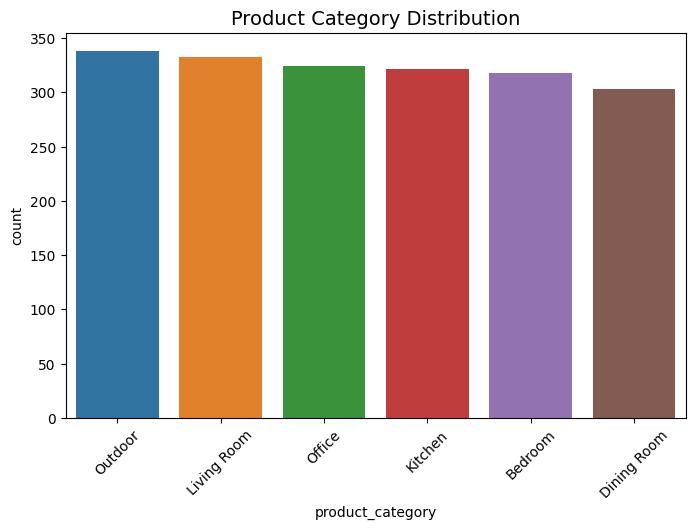

In [12]:
plt.figure(figsize=(8,5))
sns.countplot(x="product_category", data=df, order=df["product_category"].value_counts().index)
plt.title("Product Category Distribution", fontsize=14)
plt.xticks(rotation=45)
plt.show()

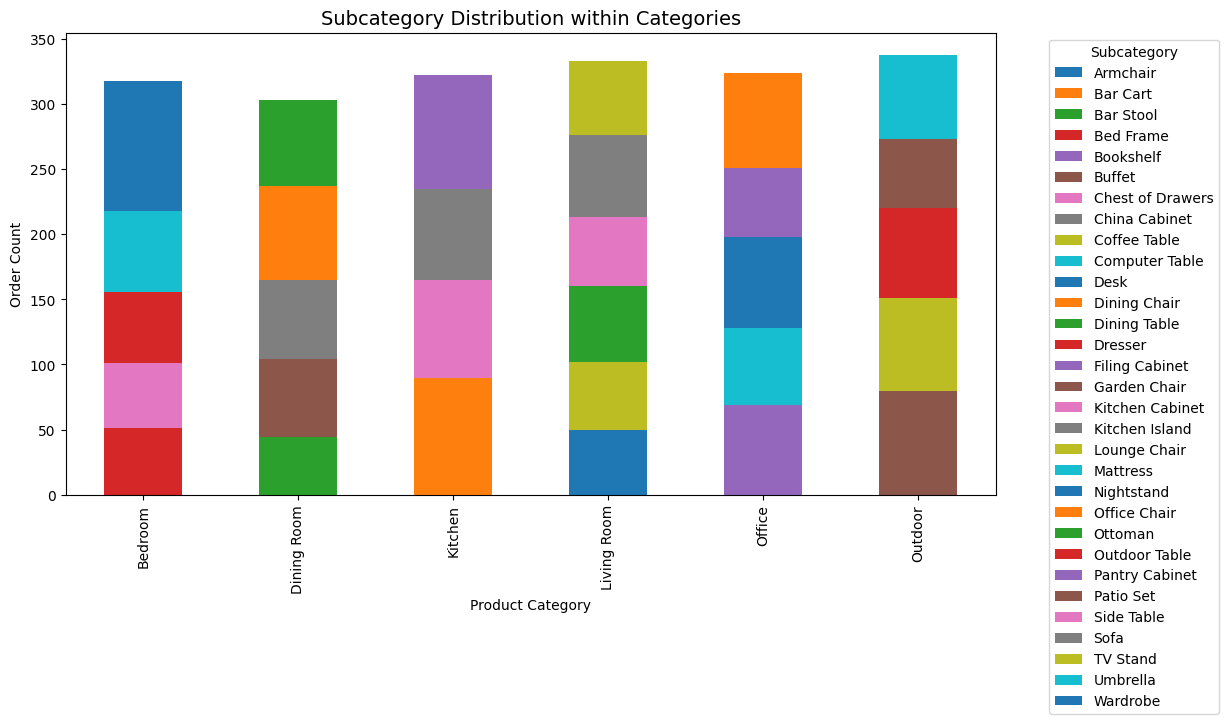

In [13]:
subcategory_counts = df.groupby(["product_category","product_subcategory"]).size().unstack().fillna(0)
subcategory_counts.plot(kind="bar", stacked=True, figsize=(12,6))
plt.title("Subcategory Distribution within Categories", fontsize=14)
plt.xlabel("Product Category")
plt.ylabel("Order Count")
plt.legend(title="Subcategory", bbox_to_anchor=(1.05, 1))
plt.show()

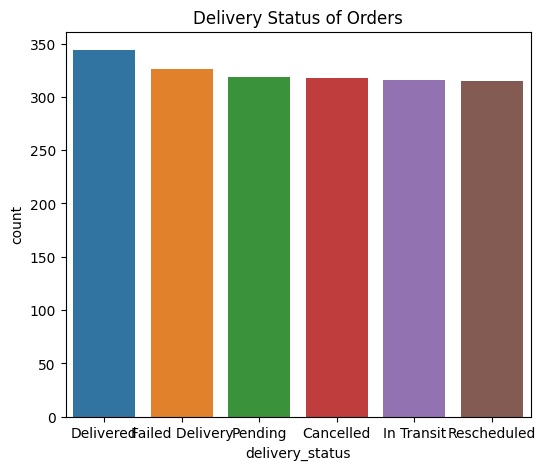

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(x="delivery_status", data=df, order=df["delivery_status"].value_counts().index)
plt.title("Delivery Status of Orders")
plt.show()

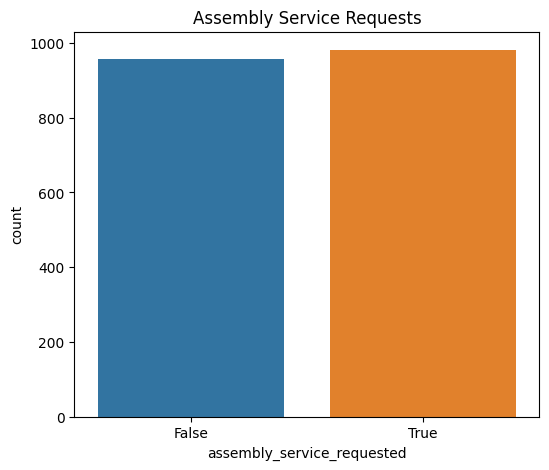

In [15]:
plt.figure(figsize=(6,5))
sns.countplot(x="assembly_service_requested", data=df)
plt.title("Assembly Service Requests")
plt.show()

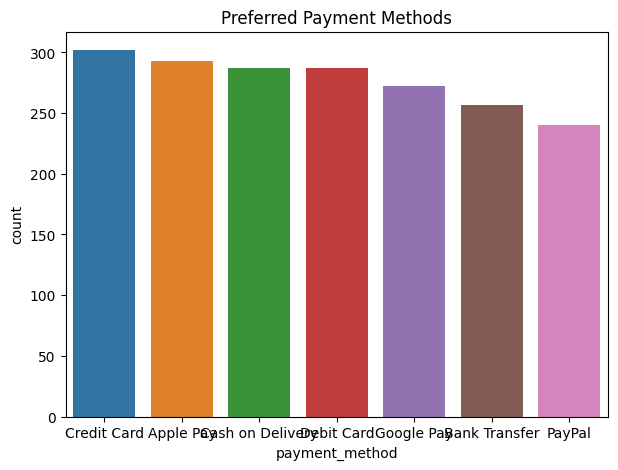

In [16]:
plt.figure(figsize=(7,5))
sns.countplot(x="payment_method", data=df, order=df["payment_method"].value_counts().index)
plt.title("Preferred Payment Methods")
plt.show()

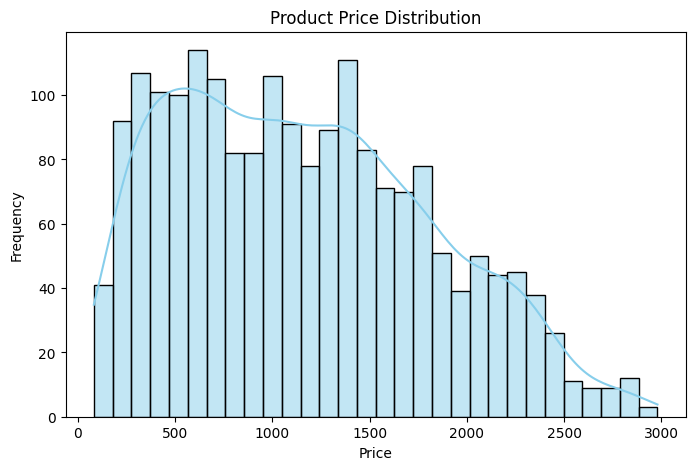

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df["product_price"], bins=30, kde=True, color="skyblue")
plt.title("Product Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

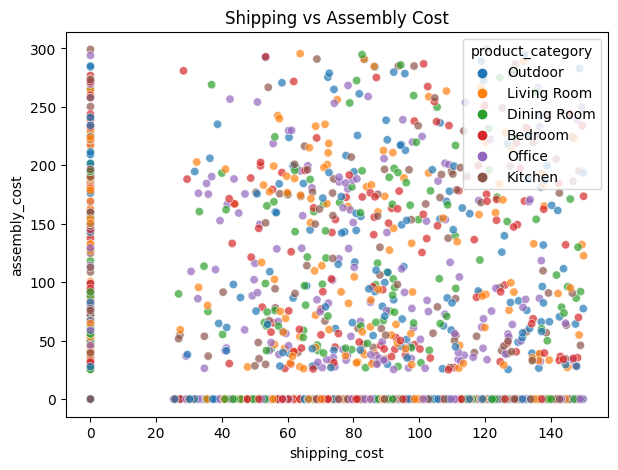

In [18]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="shipping_cost", y="assembly_cost", hue="product_category", data=df, alpha=0.7)
plt.title("Shipping vs Assembly Cost")
plt.show()

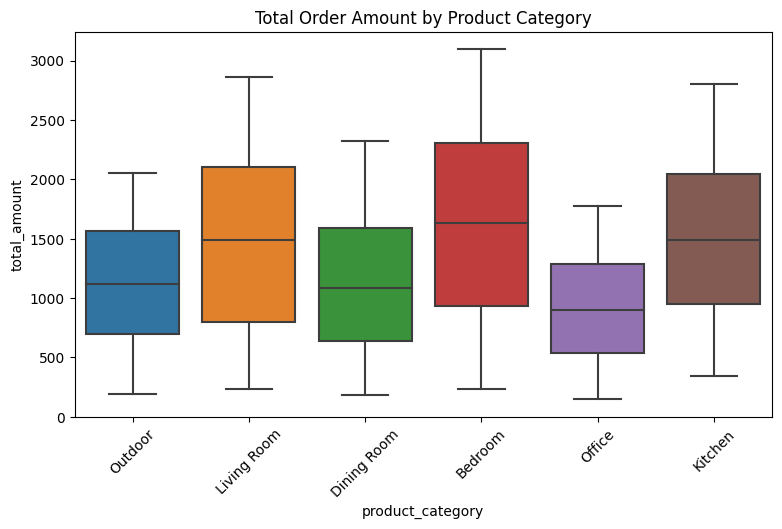

In [19]:
plt.figure(figsize=(9,5))
sns.boxplot(x="product_category", y="total_amount", data=df)
plt.title("Total Order Amount by Product Category")
plt.xticks(rotation=45)
plt.show()

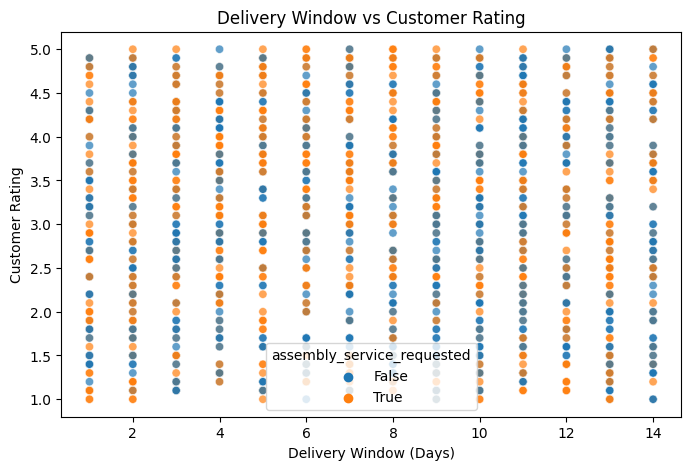

In [20]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="delivery_window_days", y="customer_rating", hue="assembly_service_requested", data=df, alpha=0.7)
plt.title("Delivery Window vs Customer Rating")
plt.xlabel("Delivery Window (Days)")
plt.ylabel("Customer Rating")
plt.show()


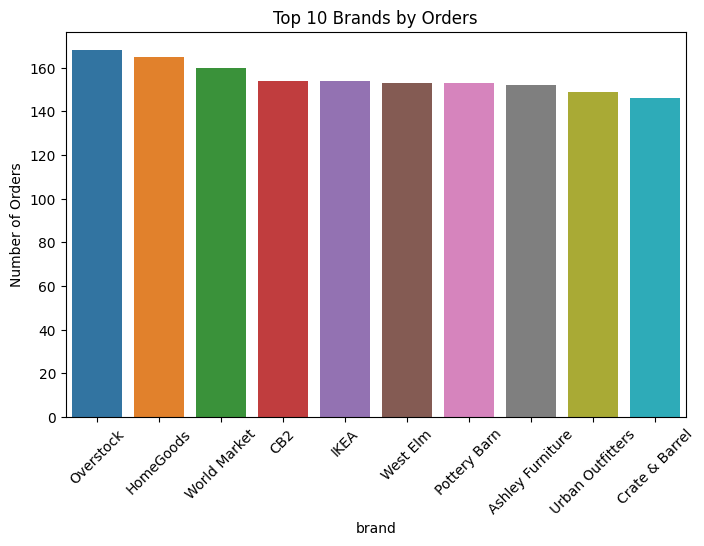

In [21]:
top_brands = df["brand"].value_counts().head(10)
plt.figure(figsize=(8,5))
sns.barplot(x=top_brands.index, y=top_brands.values)
plt.title("Top 10 Brands by Orders")
plt.xticks(rotation=45)
plt.ylabel("Number of Orders")
plt.show()

## Predictive modeling

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix

# Classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB


In [23]:
df['delivery_target'] = df['delivery_status'].apply(lambda x: 1 if str(x).lower() == 'delivered' else 0)

features = [
    'product_price', 'shipping_cost', 'assembly_cost',
    'total_amount', 'delivery_window_days', 'customer_rating',
    'assembly_service_requested', 'payment_method'
]
X = df[features]
y = df['delivery_target']

# -----------------------------
# 2) Preprocessing with Imputers
# -----------------------------
categorical_features = ['payment_method']
numeric_features = [col for col in X.columns if col not in categorical_features]

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', sparse=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# -----------------------------
# 3) Train/Test Split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 4) Models
# -----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=False, random_state=42),
    "Naive Bayes": GaussianNB()
}


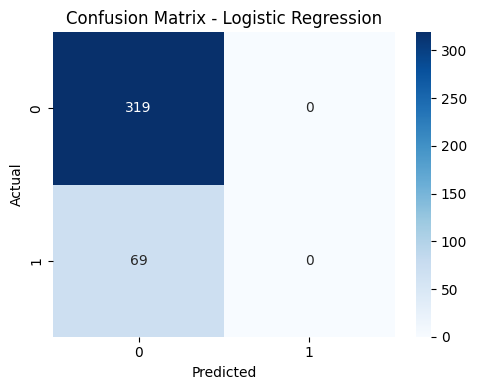

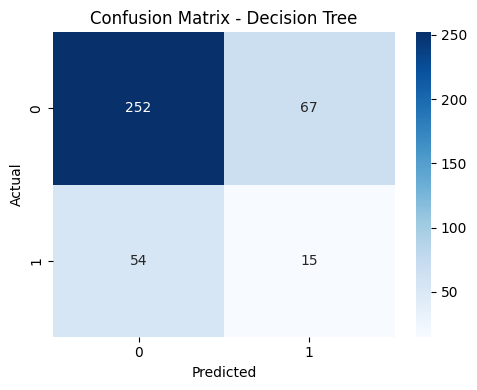

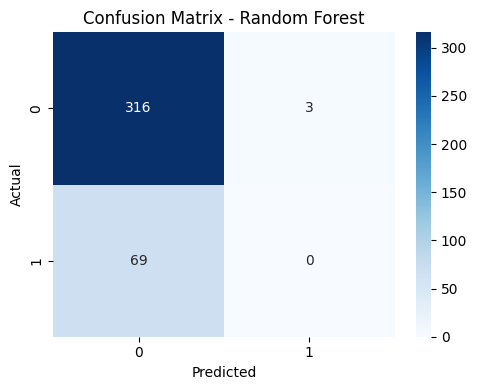

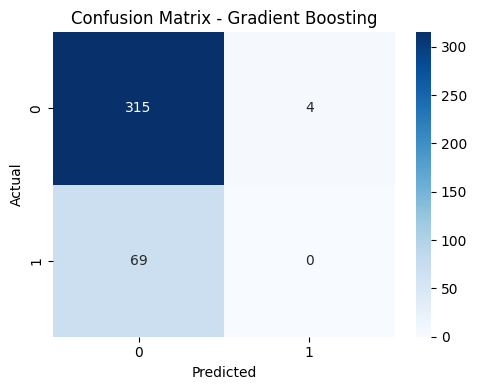

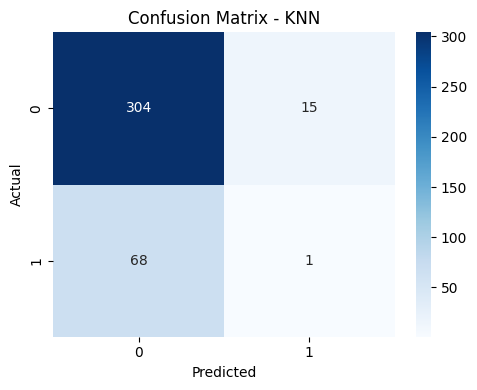

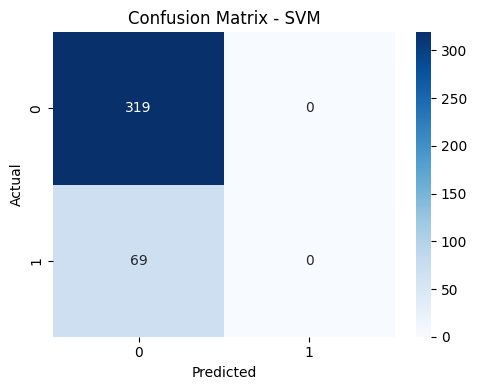

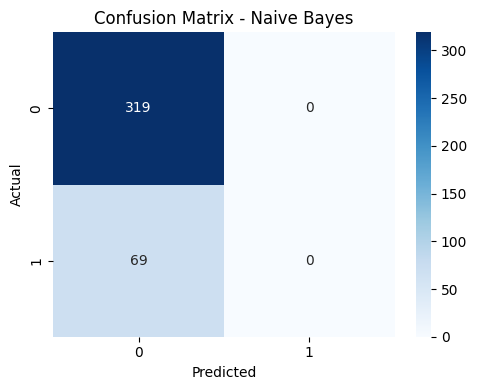

In [24]:
results = []
for name, clf in models.items():
    pipe = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    results.append({"Algorithm": name, "Accuracy (%)": round(acc, 2)})

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [25]:
results_df = pd.DataFrame(results).sort_values("Accuracy (%)", ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

          Algorithm  Accuracy (%)
Logistic Regression         82.22
                SVM         82.22
        Naive Bayes         82.22
      Random Forest         81.44
  Gradient Boosting         81.19
                KNN         78.61
      Decision Tree         68.81


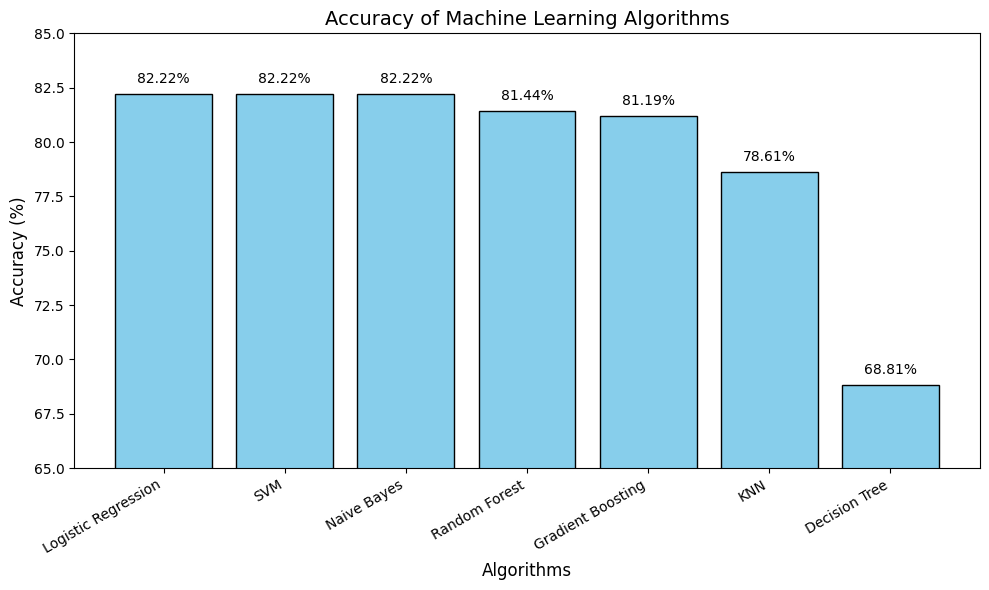

In [26]:
results = {
    "Logistic Regression": 82.22,
    "SVM": 82.22,
    "Naive Bayes": 82.22,
    "Random Forest": 81.44,
    "Gradient Boosting": 81.19,
    "KNN": 78.61,
    "Decision Tree": 68.81
}

# Plot
plt.figure(figsize=(10,6))
plt.bar(results.keys(), results.values(), color='skyblue', edgecolor='black')

# Labels and title
plt.title("Accuracy of Machine Learning Algorithms", fontsize=14)
plt.xlabel("Algorithms", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(rotation=30, ha="right")
plt.ylim(65, 85)

# Show values on bars
for i, (algo, acc) in enumerate(results.items()):
    plt.text(i, acc + 0.5, f"{acc:.2f}%", ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## Thank you...pls upvote!!!!